Using device: cuda (Please ensure GPU is turned ON in Colab settings)
Using Colab cache for faster access to the 'mnist-dataset' dataset.
Data Splits configuration -> Train: 42000 | Val: 9000 | Test: 9000
✅ Exact Total Model Parameters: 20,249,642 (~20 Million)

--- Training Pipeline Triggered on GPU ---


Epoch 1/3 [Training Phase]:   0%|          | 0/329 [00:00<?, ?it/s]

✨ Epoch 1 Finished -> Train Loss: 0.2253 | Train Acc: 93.15% | Val Loss: 0.0656 | Val Acc: 97.91%



Epoch 2/3 [Training Phase]:   0%|          | 0/329 [00:00<?, ?it/s]

✨ Epoch 2 Finished -> Train Loss: 0.0647 | Train Acc: 98.09% | Val Loss: 0.0700 | Val Acc: 97.99%



Epoch 3/3 [Training Phase]:   0%|          | 0/329 [00:00<?, ?it/s]

✨ Epoch 3 Finished -> Train Loss: 0.0409 | Train Acc: 98.69% | Val Loss: 0.0486 | Val Acc: 98.67%



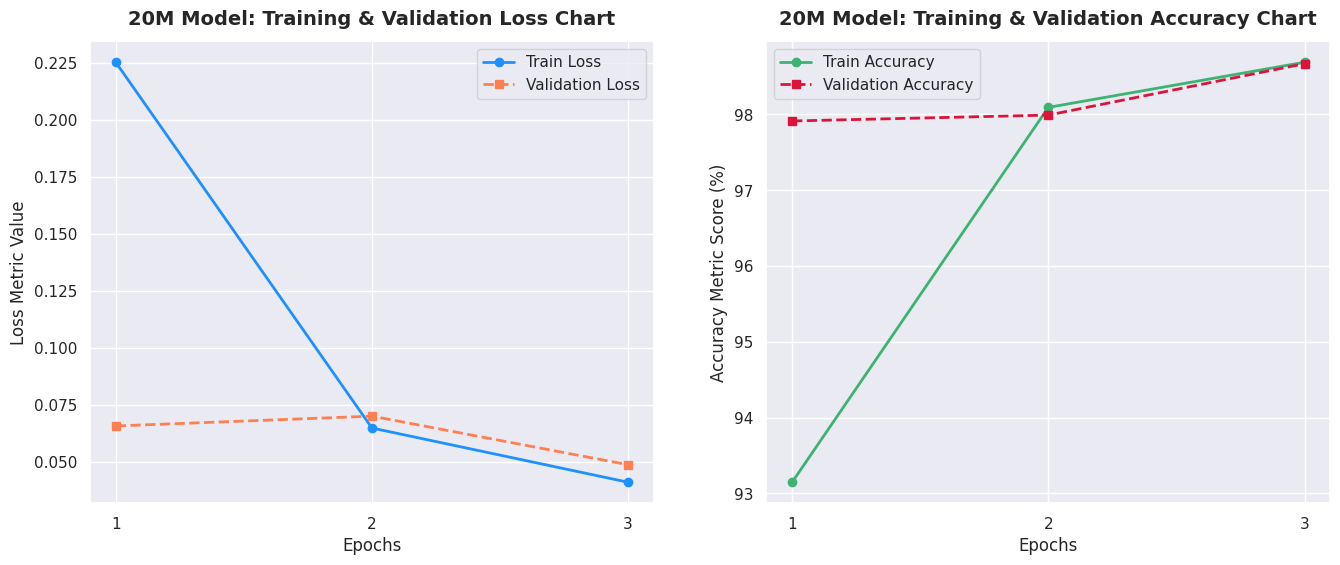


FINAL TEST ACCURACY ON 20M PYTORCH MODEL: 98.60%


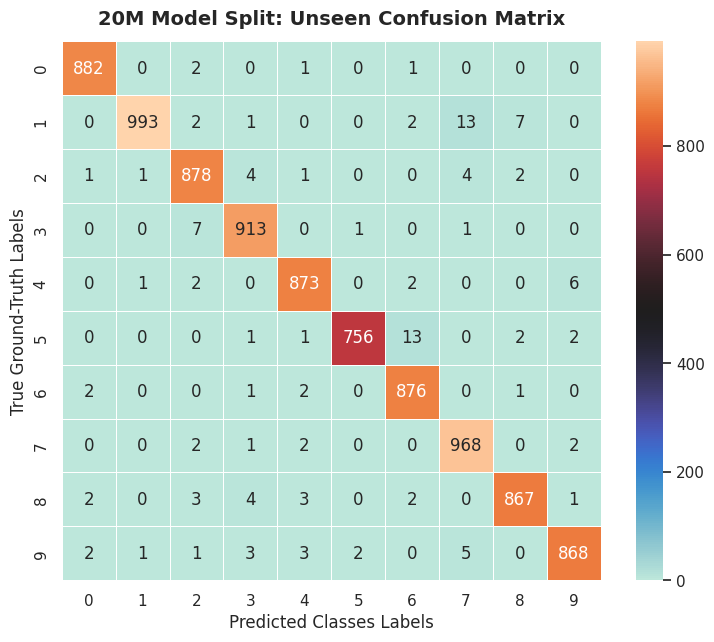

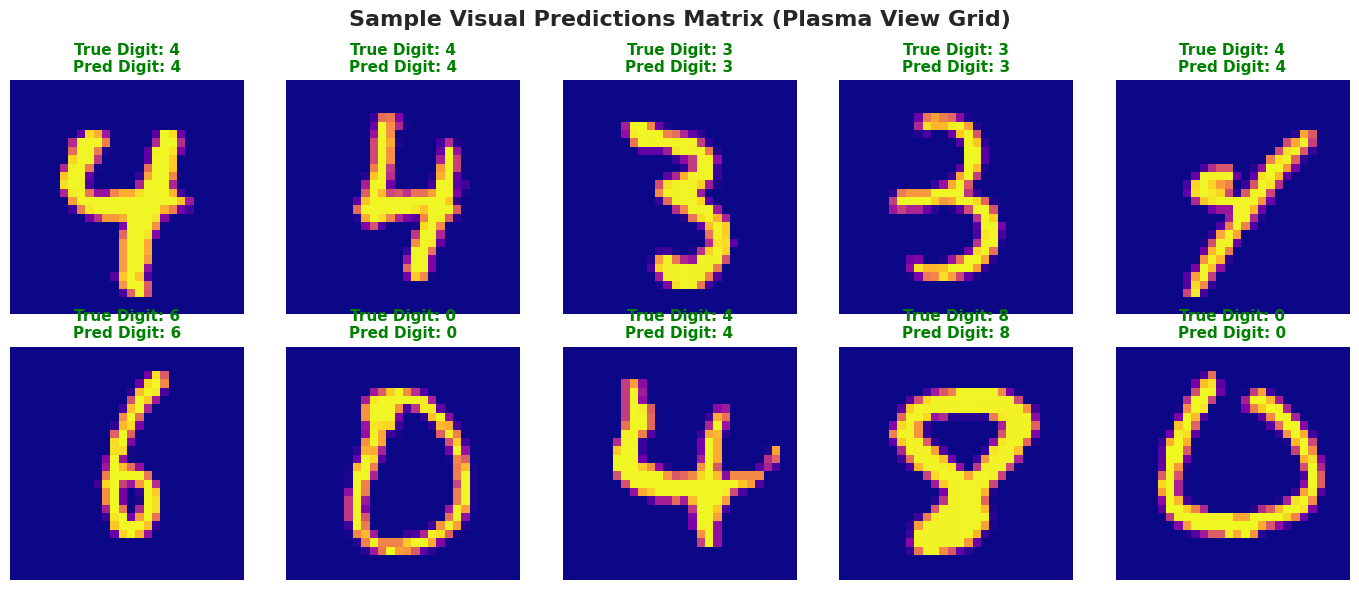

In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tqdm.notebook import tqdm
import kagglehub

# 1. GPU Verification (Crucial for 20M model)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device} (Please ensure GPU is turned ON in Colab settings)")

# 2. Download Dataset via kagglehub in the new notebook
print("Downloading MNIST dataset...")
path = kagglehub.dataset_download("hojjatk/mnist-dataset")

def find_file(base_path, target_name):
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if target_name in file:
                return os.path.join(root, file)
    raise FileNotFoundError(f"File containing '{target_name}' not found.")

train_images_path = find_file(path, 'train-images')
train_labels_path = find_file(path, 'train-labels')

# 3. Custom PyTorch Dataset to read the raw downloaded binary data
class MNISTFromKaggle(Dataset):
    def __init__(self, images_path, labels_path, transform=None):
        with open(images_path, 'rb') as f:
            # Skip 16 bytes metadata
            images = np.frombuffer(f.read(), np.uint8, offset=16)
        self.images = images.reshape(-1, 1, 28, 28).astype(np.float32) / 255.0

        with open(labels_path, 'rb') as f:
            # Skip 8 bytes metadata
            self.labels = np.frombuffer(f.read(), np.uint8, offset=8).astype(np.int64)

        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        # Apply normalization transform if provided
        if self.transform:
            image = torch.tensor(image)
            image = self.transform(image)

        return image, label

# Standard MNIST Normalization Transform
mnist_transform = transforms.Normalize((0.1307,), (0.3081,))

# Load dataset into PyTorch format
full_dataset = MNISTFromKaggle(train_images_path, train_labels_path, transform=mnist_transform)
total_len = len(full_dataset)

# 4. Strict 70/15/15 Split Selection (Total 60,000 images from the file)
train_len = int(total_len * 0.70)   # 42,000 images
val_len = int(total_len * 0.15)     # 9,000 images
test_len = total_len - train_len - val_len # 9,000 images

torch.manual_seed(42)
train_set, val_set, test_set = random_split(full_dataset, [train_len, val_len, test_len])

# Data Loaders with Batches for high-speed GPU processing
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader = DataLoader(val_set, batch_size=256, shuffle=False)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False)

print(f"Data Splits configuration -> Train: {train_len} | Val: {val_len} | Test: {test_len}")

# 5. Designing the Heavy 20 Million (20M) Parameter CNN Model Architecture
class HeavyCNN(nn.Module):
    def __init__(self):
        super(HeavyCNN, self).__init__()
        # Convolutional extraction layers
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # Output Matrix: 128 channels x 14 x 14 pixels
        )
        # Deep Dense block designed to scale weights up to ~20 Million parameters
        self.classifier = nn.Sequential(
            nn.Linear(128 * 14 * 14, 800), # 128 * 14 * 14 = 25,088 input connections to 800 hidden nodes
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(800, 128),
            nn.ReLU(),
            nn.Linear(128, 10) # 10 classification outputs
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1) # Flatten the tensor maps
        x = self.classifier(x)
        return x

model = HeavyCNN().to(device)

# Count exact total parameters inside this model architecture
total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Exact Total Model Parameters: {total_params:,} (~20 Million)")

# Loss Objective and Adam Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 6. Training Execution Loop with Live History Monitoring
epochs = 3
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\n--- Training Pipeline Triggered on GPU ---")
for epoch in range(epochs):
    # Train stage
    model.train()
    train_loss, train_correct = 0.0, 0
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Training Phase]")

    for images, labels in train_loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += torch.sum(preds == labels.data).item()

    # Validation stage
    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels.data).item()

    # Compile history records
    epoch_train_loss = train_loss / train_len
    epoch_train_acc = (train_correct / train_len) * 100
    epoch_val_loss = val_loss / val_len
    epoch_val_acc = (val_correct / val_len) * 100

    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    print(f"✨ Epoch {epoch+1} Finished -> Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%\n")

# 7. METPLOTLIB & SEABORN VISUALIZATION GENERATOR
sns.set_theme(style="darkgrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Visual Plot 1: Performance Loss curves
ax1.plot(range(1, epochs + 1), history['train_loss'], 'o-', label='Train Loss', color='dodgerblue', linewidth=2)
ax1.plot(range(1, epochs + 1), history['val_loss'], 's--', label='Validation Loss', color='coral', linewidth=2)
ax1.set_title('20M Model: Training & Validation Loss Chart', fontsize=14, weight='bold', pad=12)
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss Metric Value')
ax1.set_xticks(range(1, epochs + 1))
ax1.legend()

# Visual Plot 2: Performance Accuracy curves
ax2.plot(range(1, epochs + 1), history['train_acc'], 'o-', label='Train Accuracy', color='mediumseagreen', linewidth=2)
ax2.plot(range(1, epochs + 1), history['val_acc'], 's--', label='Validation Accuracy', color='crimson', linewidth=2)
ax2.set_title('20M Model: Training & Validation Accuracy Chart', fontsize=14, weight='bold', pad=12)
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy Metric Score (%)')
ax2.set_xticks(range(1, epochs + 1))
ax2.legend()
plt.show()

# 8. Unseen Test Evaluation & Advanced Metrics Plots
model.eval()
test_preds, test_trues = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        test_preds.extend(preds.cpu().numpy())
        test_trues.extend(labels.numpy())

test_acc = np.mean(np.array(test_preds) == np.array(test_trues)) * 100
print(f"\n===========================================\nFINAL TEST ACCURACY ON 20M PYTORCH MODEL: {test_acc:.2f}%\n===========================================")

# Visual Plot 3: Matrix Grid Breakdown (Icefire Color palette skin)
cm = confusion_matrix(test_trues, test_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='icefire', linewidths=0.5, square=True)
plt.title(f"20M Model Split: Unseen Confusion Matrix", fontsize=14, weight='bold', pad=12)
plt.xlabel("Predicted Classes Labels")
plt.ylabel("True Ground-Truth Labels")
plt.show()

# Visual Plot 4: Sample Prediction Matrix Images Display Grid
plt.figure(figsize=(14, 6))
plt.suptitle("Sample Visual Predictions Matrix (Plasma View Grid)", fontsize=16, weight='bold', y=0.98)

for idx in range(10):
    plt.subplot(2, 5, idx + 1)
    # Extract structural array matrix out of the data pool tensor
    img = test_set[idx][0].squeeze().numpy()
    actual = int(test_trues[idx])
    pred = int(test_preds[idx])
    title_color = 'green' if actual == pred else 'red'

    plt.imshow(img, cmap='plasma')
    plt.title(f"True Digit: {actual}\nPred Digit: {pred}", color=title_color, fontsize=11, weight='bold', pad=6)
    plt.axis('off')
plt.tight_layout()
plt.show()
